In [ ]:

!pip install tensorflow tf-keras transformers==4.41.2 pandas numpy scikit-learn

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["USE_TF"] = "1"

import tensorflow as tf
import transformers
print(f"TensorFlow Sürümü: {tf.__version__}")
print(f"Transformers Sürümü: {transformers.__version__}")

from transformers import AutoTokenizer, TFBertModel, BertConfig

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model

from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    print("Drive bağlantısı atlandı veya zaten bağlı.")

tf.random.set_seed(42)
np.random.seed(42)

print("\nMÜKEMMEL! Tüm kütüphaneler başarıyla yüklendi ve TFBertModel hazır.")

TensorFlow Sürümü: 2.20.0
Transformers Sürümü: 4.41.2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

MÜKEMMEL! Tüm kütüphaneler başarıyla yüklendi ve TFBertModel hazır.


In [ ]:
# 3. HÜCRE: METİN TEMİZLEME FONKSİYONU
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Türkçe karakter uyumlu olarak tüm harfleri küçült
    text = text.lower()

    # 2. Varsa linkleri (http/www) temizle
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Yeni satır ve sekme karakterlerini tek bir boşluğa çevir
    text = re.sub(r'[\r\n\t]+', ' ', text)

    # 4. SADECE harfler, rakamlar ve temel noktalama işaretleri kalsın (.,!?)
    # Çünkü House'un ünlemleri (duygu) ve soru işaretleri (niyet) model için çok önemli.
    text = re.sub(r'[^a-z0-9çğıöşü.,!? ]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("clean_text fonksiyonu tanımlandı.")

clean_text fonksiyonu tanımlandı.


In [ ]:
# 4. HÜCRE: VERİ OKUMA VE ETİKET GRUPLAMA (MAPPING)
import pandas as pd

# Drive'daki dosya yolunuz (Eğer farklı bir klasörde değilse direkt çalışacaktır)
file_path = '/content/drive/MyDrive/Last_HouseMD_DataSet.xlsx'

print("Veri seti yükleniyor...")
df = pd.read_excel(file_path)
print(f"Ham Veri Seti Boyutu: {len(df)} satır.")

# -------------------------------------------------------------
# ADIM 1: REPLİK (TEXT) TEMİZLİĞİ
# -------------------------------------------------------------
df['clean_text'] = df['text'].apply(clean_text)
# Temizlik sonrası tamamen boş kalan satırları siliyoruz
df = df[df['clean_text'].str.strip() != ""]

# -------------------------------------------------------------
# ADIM 2: SARCASM (ALAYCILIK) SÜTUNUNU DÜZELTME
# -------------------------------------------------------------
# Sadece "0" ve "1" değerlerini kabul edip, hatalı stringleri temizliyoruz.
df['Sarcasm'] = pd.to_numeric(df['Sarcasm'], errors='coerce')
df = df.dropna(subset=['Sarcasm']) 
df['Sarcasm'] = df['Sarcasm'].astype(int)
df = df[df['Sarcasm'].isin([0, 1])]

# -------------------------------------------------------------
# ADIM 3: EMOTION (DUYGU) GRUPLAMA
# -------------------------------------------------------------
emotion_mapping = {
    'nötr': 'Nötr/Ciddi', 'ciddi': 'Nötr/Ciddi', 'Ciddi': 'Nötr/Ciddi', 'Tarafsız': 'Nötr/Ciddi', 'Sakin': 'Nötr/Ciddi',
    'alaycı': 'Alaycı', 'Alaycı': 'Alaycı',
    'endişe': 'Kaygılı/Korkmuş', 'Panik': 'Kaygılı/Korkmuş', 'panik': 'Kaygılı/Korkmuş', 'endişeli': 'Kaygılı/Korkmuş', 'Korku': 'Kaygılı/Korkmuş',
    'empati': 'Empatik/Düşünceli', 'düşünceli': 'Empatik/Düşünceli', 'üzgün': 'Empatik/Düşünceli',
    'şaşkın': 'Şaşkın',
    'kararlı': 'Kararlı/Emin', 'emin': 'Kararlı/Emin', 'Analitik': 'Kararlı/Emin', 'analitik': 'Kararlı/Emin'
}
df['Emotion_Grouped'] = df['Emotion'].map(emotion_mapping).fillna('Nötr/Ciddi')

# -------------------------------------------------------------
# ADIM 4: INTENT (NİYET) GRUPLAMA
# -------------------------------------------------------------
intent_mapping = {
    'açıklama': 'Açıklama', 'Açıklama': 'Açıklama',
    'hipotez': 'Hipotez/Fikir', 'Gözlem': 'Hipotez/Fikir', 'Durum değerlendirme': 'Hipotez/Fikir', 'değerlendirme': 'Hipotez/Fikir',
    'soru': 'Soru',
    'talimat': 'Talimat/Tedavi', 'emir': 'Talimat/Tedavi', 'tedavi': 'Talimat/Tedavi', 'Tedavi': 'Talimat/Tedavi',
    'itiraz': 'İtiraz',
    'tanı': 'Tanı/Test', 'Tanı': 'Tanı/Test', 'test': 'Tanı/Test'
}
df['Intent_Grouped'] = df['Intent'].map(intent_mapping).fillna('Açıklama')

# -------------------------------------------------------------
# ADIM 5: AŞAMA (DIAGNOSIS STAGE) GRUPLAMA
# -------------------------------------------------------------
stage_mapping = {
    'hipotez': 'Hipotez/Değerlendirme', 'değerlendirme': 'Hipotez/Değerlendirme',
    'test': 'Test/Tanı', 'kesin_tanı': 'Test/Tanı', 'Tanı süreci': 'Test/Tanı',
    'tedavi': 'Tedavi/Müdahale', 'ameliyat': 'Tedavi/Müdahale', 'Tedavi talimatı': 'Tedavi/Müdahale'
}
df['Stage_Grouped'] = df['diagnosis_stage'].map(stage_mapping).fillna('Diğer')

print(f"Temizlenmiş Veri Seti Boyutu: {len(df)} satır.")

Veri seti yükleniyor...
Ham Veri Seti Boyutu: 7282 satır.
Temizlenmiş Veri Seti Boyutu: 7088 satır.


In [ ]:
# 5. HÜCRE: LABEL ENCODING VE CLASS WEIGHTS (SINIF AĞIRLIKLARI)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Etiketler sayısallaştırılıyor...")

intent_labels, intent_uniques = pd.factorize(df['Intent_Grouped'])
stage_labels, stage_uniques = pd.factorize(df['Stage_Grouped'])
emotion_labels, emotion_uniques = pd.factorize(df['Emotion_Grouped'])

label_mappings = {
    'Intent': list(intent_uniques),
    'Stage': list(stage_uniques),
    'Emotion': list(emotion_uniques)
}

print("\nEtiket Sınıfları Sözlüğü:")
print(label_mappings)

def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

intent_weights = get_class_weights(intent_labels)
stage_weights = get_class_weights(stage_labels)
emotion_weights = get_class_weights(emotion_labels)
sarcasm_weights = get_class_weights(df['Sarcasm'].values)

print("\nSınıf Ağırlıkları (Class Weights) başarıyla hesaplandı.")

Etiketler sayısallaştırılıyor...

Etiket Sınıfları Sözlüğü:
{'Intent': ['Açıklama', 'Hipotez/Fikir', 'Soru', 'Tanı/Test', 'Talimat/Tedavi', 'İtiraz'], 'Stage': ['Hipotez/Değerlendirme', 'Test/Tanı', 'Diğer', 'Tedavi/Müdahale'], 'Emotion': ['Nötr/Ciddi', 'Alaycı', 'Empatik/Düşünceli', 'Kaygılı/Korkmuş', 'Kararlı/Emin', 'Şaşkın']}

Sınıf Ağırlıkları (Class Weights) başarıyla hesaplandı.


In [ ]:
# 6. HÜCRE: TOKENIZATION VE VERİ BÖLME
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

MODEL_NAME = 'ytu-ce-cosmos/turkish-small-bert-uncased'

print(f"{MODEL_NAME} sözlüğü (Tokenizer) indiriliyor...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

max_len = 128 

print("Metinler tokenize ediliyor (Bu işlem birkaç saniye sürebilir)...")
X_tokens = tokenizer(
    text=df['clean_text'].tolist(),
    add_special_tokens=True,
    max_length=max_len,
    truncation=True,
    padding='max_length',
    return_tensors='tf',
    return_attention_mask=True,
    return_token_type_ids=False
)

# Girdi verilerimiz (Input IDs ve Attention Mask)
X_input_ids = X_tokens['input_ids'].numpy()
X_attention_masks = X_tokens['attention_mask'].numpy()

# Çıktı verilerimiz (Hedef değişkenler)
y_sarcasm = df['Sarcasm'].values
y_intent = intent_labels
y_stage = stage_labels
y_emotion = emotion_labels

# 1. Aşama: Veriyi Eğitim (%80) ve Geçici (%20) olarak bölüyoruz
X_train_seq, X_temp_seq, X_train_mask, X_temp_mask, y_train_sarcasm, y_temp_sarcasm, y_train_intent, y_temp_intent, y_train_stage, y_temp_stage, y_train_emotion, y_temp_emotion = train_test_split(
    X_input_ids, X_attention_masks, y_sarcasm, y_intent, y_stage, y_emotion,
    random_state=42, test_size=0.2
)

# 2. Aşama: Geçici veriyi de Doğrulama (Validation %10) ve Test (%10) olarak ikiye bölüyoruz
X_val_seq, X_test_seq, X_val_mask, X_test_mask, y_val_sarcasm, y_test_sarcasm, y_val_intent, y_test_intent, y_val_stage, y_test_stage, y_val_emotion, y_test_emotion = train_test_split(
    X_temp_seq, X_temp_mask, y_temp_sarcasm, y_temp_intent, y_temp_stage, y_temp_emotion,
    random_state=42, test_size=0.5
)

print("\n--- Veri Bölünme Özeti ---")
print(f"Eğitim Verisi (Train): {len(X_train_seq)}")
print(f"Doğrulama Verisi (Validation): {len(X_val_seq)}")
print(f"Test Verisi (Test): {len(X_test_seq)}")

ytu-ce-cosmos/turkish-small-bert-uncased sözlüğü (Tokenizer) indiriliyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Metinler tokenize ediliyor (Bu işlem birkaç saniye sürebilir)...

--- Veri Bölünme Özeti ---
Eğitim Verisi (Train): 5670
Doğrulama Verisi (Validation): 709
Test Verisi (Test): 709


In [ ]:
# 7. HÜCRE: MULTI-TASK BERT MİMARİSİ (4 ÇIKIŞLI)
from tensorflow.keras.optimizers import Adam

print(f"{MODEL_NAME} modeli (Backbone) yükleniyor...")

def build_multi_task_model():
    # 1. Girdi Katmanları (Tokenlar ve Maskeler)
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')

    # 2. Önceden eğitilmiş BERT modeli (Gövde)
    bert_model = TFBertModel.from_pretrained(MODEL_NAME)

    # İnce ayar (Fine-tuning) yapabilmek için BERT'in ağırlıklarını eğitime açıyoruz
    bert_model.trainable = True

    # BERT'ten çıkan [CLS] token vektörünü alıyoruz (Cümlenin genel anlamsal özeti)
    bert_output = bert_model(input_ids, attention_mask=attention_mask)
    cls_token = bert_output.pooler_output

    # Ortak bir Dropout katmanı ekleyerek ezberlemeyi (overfitting) önlüyoruz
    x = Dropout(0.3)(cls_token)

    # 3. BAĞIMSIZ ÇIKIŞ KAFALARI (DENSE HEADS)

    # A) Sarcasm Çıkışı (Binary: 0 veya 1) -> Sigmoid
    out_sarcasm = Dense(1, activation='sigmoid', name='sarcasm_output')(x)

    # B) Intent Çıkışı (Çoklu sınıf) -> Softmax
    out_intent = Dense(len(intent_uniques), activation='softmax', name='intent_output')(x)

    # C) Stage Çıkışı (Çoklu sınıf) -> Softmax
    out_stage = Dense(len(stage_uniques), activation='softmax', name='stage_output')(x)

    # D) Emotion Çıkışı (Çoklu sınıf) -> Softmax
    out_emotion = Dense(len(emotion_uniques), activation='softmax', name='emotion_output')(x)

    # 4. Modeli Toparlama
    model = Model(
        inputs=[input_ids, attention_mask],
        outputs=[out_sarcasm, out_intent, out_stage, out_emotion]
    )

    # 5. Derleme (Compile)
    losses = {
        'sarcasm_output': 'binary_crossentropy',
        'intent_output': 'sparse_categorical_crossentropy',
        'stage_output': 'sparse_categorical_crossentropy',
        'emotion_output': 'sparse_categorical_crossentropy'
    }

    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss=losses,
        metrics=['accuracy']
    )

    return model

model = build_multi_task_model()
print("\nModel Mimarisi Başarıyla Kuruldu!")
model.summary()

ytu-ce-cosmos/turkish-small-bert-uncased modeli (Backbone) yükleniyor...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w


Model Mimarisi Başarıyla Kuruldu!
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   2952038   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   4          'attention_mask[0][0]']      
                             hidden_state=(None, 128, 5    

In [ ]:
# 8. HÜCRE: MODEL EĞİTİMİ (SAMPLE WEIGHTS İLE)
import numpy as np

def create_sample_weights(y_true, class_weights_dict):
    return np.array([class_weights_dict[int(y)] for y in y_true])

print("Örnek ağırlıkları (Sample Weights) hesaplanıyor...")
sw_sarcasm = create_sample_weights(y_train_sarcasm, sarcasm_weights)
sw_intent = create_sample_weights(y_train_intent, intent_weights)
sw_stage = create_sample_weights(y_train_stage, stage_weights)
sw_emotion = create_sample_weights(y_train_emotion, emotion_weights)

# Model eğitim parametreleri
EPOCHS = 4
BATCH_SIZE = 16

print(f"\n--- Model Eğitimi Başlıyor (Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}) ---")
print("Bu işlem Colab GPU'sunda her epoch için yaklaşık 1-3 dakika sürebilir. Lütfen bekleyin...")

history = model.fit(
    x={'input_ids': X_train_seq, 'attention_mask': X_train_mask},
    y={
        'sarcasm_output': y_train_sarcasm,
        'intent_output': y_train_intent,
        'stage_output': y_train_stage,
        'emotion_output': y_train_emotion
    },
    validation_data=(
        {'input_ids': X_val_seq, 'attention_mask': X_val_mask},
        {
            'sarcasm_output': y_val_sarcasm,
            'intent_output': y_val_intent,
            'stage_output': y_val_stage,
            'emotion_output': y_val_emotion
        }
    ),
    sample_weight={
        'sarcasm_output': sw_sarcasm,
        'intent_output': sw_intent,
        'stage_output': sw_stage,
        'emotion_output': sw_emotion
    },
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

print("\nEğitim Başarıyla Tamamlandı!")

Örnek ağırlıkları (Sample Weights) hesaplanıyor...

--- Model Eğitimi Başlıyor (Epochs: 4, Batch Size: 16) ---
Bu işlem Colab GPU'sunda her epoch için yaklaşık 1-3 dakika sürebilir. Lütfen bekleyin...
Epoch 1/4
355/355 [==============================] - 72s 117ms/step - loss: 5.8422 - sarcasm_output_loss: 0.7096 - intent_output_loss: 1.7453 - stage_output_loss: 1.4394 - emotion_output_loss: 1.9478 - sarcasm_output_accuracy: 0.5557 - intent_output_accuracy: 0.2416 - stage_output_accuracy: 0.3088 - emotion_output_accuracy: 0.1818 - val_loss: 5.1017 - val_sarcasm_output_loss: 0.5725 - val_intent_output_loss: 1.6073 - val_stage_output_loss: 1.2518 - val_emotion_output_loss: 1.6701 - val_sarcasm_output_accuracy: 0.7221 - val_intent_output_accuracy: 0.3653 - val_stage_output_accuracy: 0.4217 - val_emotion_output_accuracy: 0.2962
Epoch 2/4
355/355 [==============================] - 32s 90ms/step - loss: 4.7642 - sarcasm_output_loss: 0.6219 - intent_output_loss: 1.3305 - stage_output_loss: 1.2

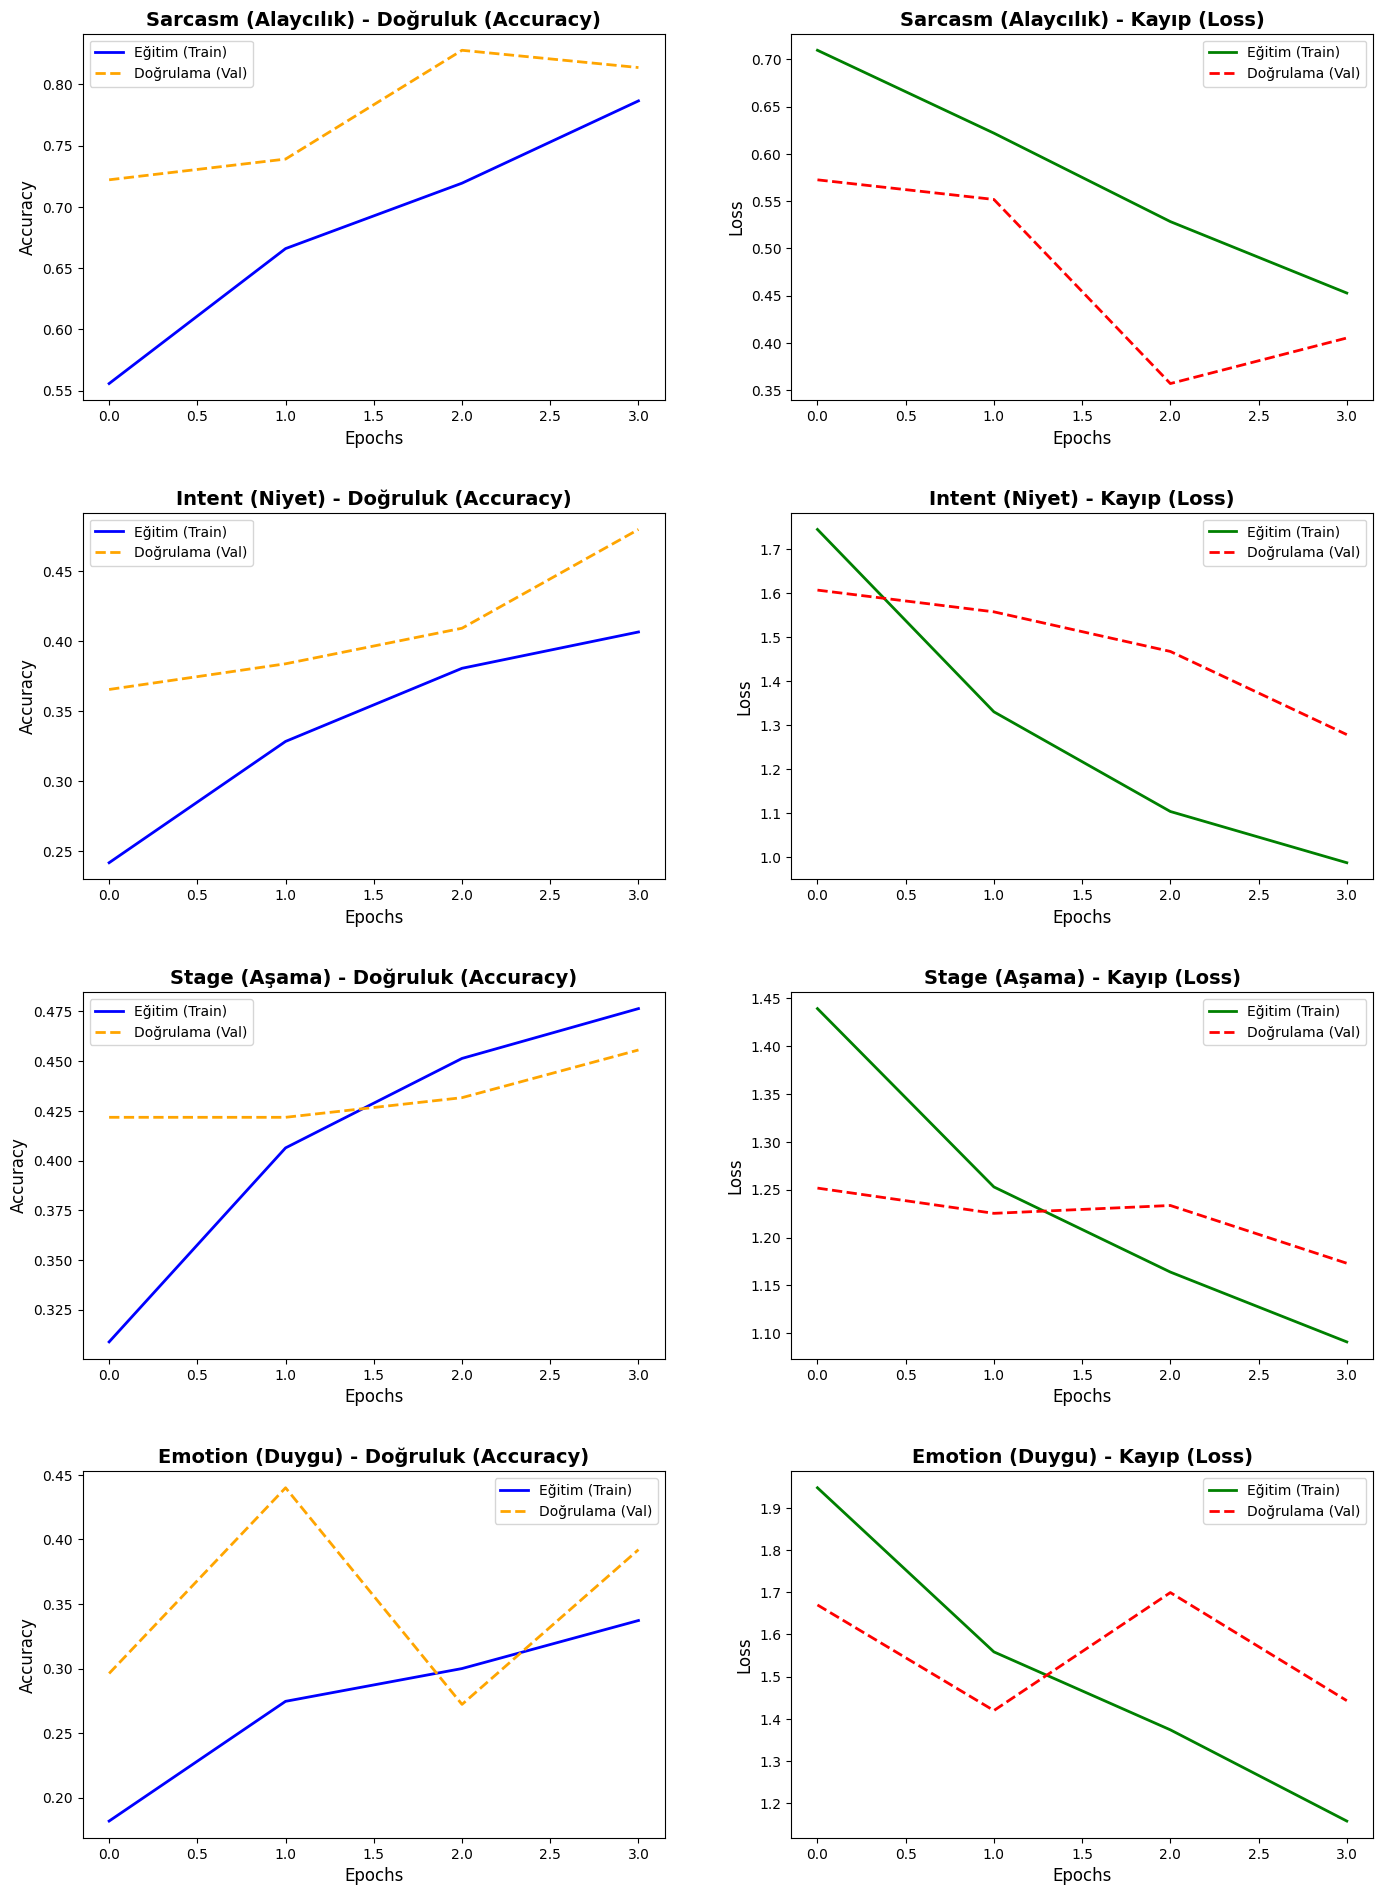

In [ ]:
# 9. HÜCRE: EĞİTİM GRAFİKLERİNİN ÇİZDİRİLMESİ

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.tight_layout(pad=6.0)

outputs = ['sarcasm_output', 'intent_output', 'stage_output', 'emotion_output']
titles = ['Sarcasm (Alaycılık)', 'Intent (Niyet)', 'Stage (Aşama)', 'Emotion (Duygu)']

for i, output_name in enumerate(outputs):
    # Doğruluk (Accuracy) Grafiği
    acc_key = f'{output_name}_accuracy'
    val_acc_key = f'val_{output_name}_accuracy'

    axes[i, 0].plot(history.history[acc_key], label='Eğitim (Train)', color='blue', linewidth=2)
    axes[i, 0].plot(history.history[val_acc_key], label='Doğrulama (Val)', color='orange', linewidth=2, linestyle='--')
    axes[i, 0].set_title(f'{titles[i]} - Doğruluk (Accuracy)', fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel('Epochs', fontsize=12)
    axes[i, 0].set_ylabel('Accuracy', fontsize=12)
    axes[i, 0].legend()

    # Kayıp (Loss) Grafiği
    loss_key = f'{output_name}_loss'
    val_loss_key = f'val_{output_name}_loss'

    axes[i, 1].plot(history.history[loss_key], label='Eğitim (Train)', color='green', linewidth=2)
    axes[i, 1].plot(history.history[val_loss_key], label='Doğrulama (Val)', color='red', linewidth=2, linestyle='--')
    axes[i, 1].set_title(f'{titles[i]} - Kayıp (Loss)', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('Epochs', fontsize=12)
    axes[i, 1].set_ylabel('Loss', fontsize=12)
    axes[i, 1].legend()

plt.show()

In [13]:
# 10. HÜCRE: İSTEDİĞİNİZ KADAR TEST EDEBİLECEĞİNİZ OYUN ALANI
print("--- MODEL TEST AŞAMASI ---")

# Buradaki cümleleri dilediğiniz gibi değiştirebilirsiniz
test_sentences = [
    "Hastanın gözlerindeki sararma karaciğerinin iflas ettiğini bas bas bağırıyor, ama siz hala inatla lupus arıyorsunuz.",
    "Kızım sabah uyandığından beri doğru düzgün nefes alamıyor ve parmak uçları morarmaya başladı, lütfen bir şey yapın!",
    "Lomber ponksiyon sonuçları tamamen temiz çıktı, yani menenjiti eleyebiliriz ancak beynindeki ödem büyümeye devam ediyor.",
    "Eğer şimdi yüksek dozda kortikosteroid verirsek bağışıklık sistemini tamamen çökertiriz, hastayı bu riske atamayız.",
    "Ailesinin evindeki o eski halı... Bu bir otoimmün hastalık değil, hasta yıllardır o halıdaki mantar sporlarını soluyor!"
]

# Metinleri modele uygun hale getirme
test_tokens = tokenizer(
    text=test_sentences,
    add_special_tokens=True,
    max_length=max_len,
    truncation=True,
    padding='max_length',
    return_tensors='tf',
    return_attention_mask=True,
    return_token_type_ids=False
)

# Tahmin yaptırma
predictions = model.predict(
    {'input_ids': test_tokens['input_ids'], 'attention_mask': test_tokens['attention_mask']}
)

# Tahminleri anlaşılır hale getirme
sarcasm_preds = (predictions[0] > 0.5).astype(int).flatten()
intent_preds = np.argmax(predictions[1], axis=1)
stage_preds = np.argmax(predictions[2], axis=1)
emotion_preds = np.argmax(predictions[3], axis=1)

print("\n--- TAHMİN SONUÇLARI ---")
for i, text in enumerate(test_sentences):
    print(f"\nCümle: {text}")
    print(f"Sarcasm: {'Evet (1)' if sarcasm_preds[i] == 1 else 'Hayır (0)'}")
    print(f"Intent : {label_mappings['Intent'][intent_preds[i]]}")
    print(f"Stage  : {label_mappings['Stage'][stage_preds[i]]}")
    print(f"Emotion: {label_mappings['Emotion'][emotion_preds[i]]}")

--- MODEL TEST AŞAMASI ---
1/1 [==============================] - 0s 160ms/step

--- TAHMİN SONUÇLARI ---

Cümle: Hastanın gözlerindeki sararma karaciğerinin iflas ettiğini bas bas bağırıyor, ama siz hala inatla lupus arıyorsunuz.
Sarcasm: Evet (1)
Intent : Açıklama
Stage  : Diğer
Emotion: Alaycı

Cümle: Kızım sabah uyandığından beri doğru düzgün nefes alamıyor ve parmak uçları morarmaya başladı, lütfen bir şey yapın!
Sarcasm: Evet (1)
Intent : Açıklama
Stage  : Diğer
Emotion: Kaygılı/Korkmuş

Cümle: Lomber ponksiyon sonuçları tamamen temiz çıktı, yani menenjiti eleyebiliriz ancak beynindeki ödem büyümeye devam ediyor.
Sarcasm: Hayır (0)
Intent : Hipotez/Fikir
Stage  : Test/Tanı
Emotion: Nötr/Ciddi

Cümle: Eğer şimdi yüksek dozda kortikosteroid verirsek bağışıklık sistemini tamamen çökertiriz, hastayı bu riske atamayız.
Sarcasm: Hayır (0)
Intent : Açıklama
Stage  : Tedavi/Müdahale
Emotion: Kararlı/Emin

Cümle: Ailesinin evindeki o eski halı... Bu bir otoimmün hastalık değil, hasta yıll

In [14]:
# 11. HÜCRE: MODELİN TFLITE DÖNÜŞÜMÜ VE CANLI ORTAMA ALINMASI (DEPLOYMENT) İÇİN KAYDEDİLMESİ

# Modeli Google Drive'a kaydediyoruz
save_path = '/content/drive/MyDrive/house_md_v2.h5'
model.save(save_path)

print(f"\nModel başarıyla '{save_path}' adresine kaydedildi.")


Model başarıyla '/content/drive/MyDrive/house_md_v2.h5' adresine kaydedildi.
